# Check Roman Observability

Given a date and sky coordinates, this notebook determines whether GalSim will permit a Roman observation and plots the zodiacal background as a function of date over the year.

Roman can only point at angles 90 ± 36° from the Sun. When that constraint is violated, `galsim.roman.getWCS` raises:

```
galsim.errors.GalSimError: Error, Roman cannot look at this position on this date!
```

This notebook lets you check the inputs (set directly or read from a mejiro config file) ahead of running the pipeline.

In [1]:
import os
import datetime

import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import galsim
from galsim import roman as gs_roman
from galsim import CelestialCoord, degrees

## Inputs

Either set `config_file` to the path of a mejiro config (the notebook will read `exposure.date` and `exposure.coordinates`), or leave `config_file = None` and set `date`, `ra`, `dec` directly below.

- `date`: `datetime.datetime` or ISO-8601 string
- `ra`, `dec`: degrees

In [10]:
# option A: read from a mejiro config file (set to None to use the direct values below)
import mejiro
# config_file = os.path.join(os.path.dirname(mejiro.__file__), 'data', 'mejiro_config', 'simple.yaml')
config_file = None

# option B: direct values (used only if config_file is None)
date = '2027-05-01T00:00:00'
ra = 150.0
dec = 2.0

In [11]:
def _to_datetime(val):
    if isinstance(val, datetime.datetime):
        return val
    if isinstance(val, datetime.date):
        return datetime.datetime(val.year, val.month, val.day)
    return datetime.datetime.fromisoformat(str(val))

if config_file is not None:
    with open(config_file, 'r') as f:
        config = yaml.load(f, Loader=yaml.SafeLoader)
    exposure = config['exposure']
    date = exposure['date']
    ra = float(exposure['coordinates']['ra'])
    dec = float(exposure['coordinates']['dec'])
    print(f'Loaded inputs from {config_file}')

date = _to_datetime(date)
world_pos = CelestialCoord(ra * degrees, dec * degrees)

print(f'date: {date.isoformat()}')
print(f'ra,  dec: {ra:.6f}, {dec:.6f} deg')

date: 2027-05-01T00:00:00
ra,  dec: 150.000000, 2.000000 deg


## Observability check

`galsim.roman.allowedPos` returns `True` if the Sun–target angle falls within 90 ± `max_sun_angle` (36°) on the supplied date.

In [12]:
import coord as _coord

def sun_target_angle_deg(world_pos, date):
    lam = _coord.util.sun_position_ecliptic(date)
    sun = _coord.CelestialCoord.from_ecliptic(lam, 0 * _coord.radians, date.year)
    return abs(world_pos.distanceTo(sun) / _coord.degrees)

allowed = gs_roman.allowedPos(world_pos, date)
ang = sun_target_angle_deg(world_pos, date)
min_ang = 90.0 - gs_roman.max_sun_angle
max_ang = 90.0 + gs_roman.max_sun_angle

print(f'Sun-target angle on {date.date()}: {ang:.2f} deg')
print(f'Allowed range: [{min_ang:.2f}, {max_ang:.2f}] deg')
if allowed:
    print('OBSERVATION ALLOWED')
else:
    deficit = min(abs(ang - min_ang), abs(ang - max_ang))
    print(f'OBSERVATION NOT ALLOWED (off by {deficit:.2f} deg)')

Sun-target angle on 2027-05-01: 110.65 deg
Allowed range: [54.00, 126.00] deg
OBSERVATION ALLOWED


## Allowed-date windows over the year

Scan a year centered on the requested date at daily cadence, flag which days satisfy the pointing constraint, and report the contiguous allowed windows.

In [13]:
start = date - datetime.timedelta(days=183)
end = date + datetime.timedelta(days=183)
days = [start + datetime.timedelta(days=i) for i in range((end - start).days + 1)]

angles = np.array([sun_target_angle_deg(world_pos, d) for d in days])
allowed_mask = (angles >= min_ang) & (angles <= max_ang)

# contiguous True runs -> (start_date, end_date) windows
windows = []
i = 0
while i < len(allowed_mask):
    if allowed_mask[i]:
        j = i
        while j + 1 < len(allowed_mask) and allowed_mask[j + 1]:
            j += 1
        windows.append((days[i].date(), days[j].date()))
        i = j + 1
    else:
        i += 1

print(f'Allowed windows within {start.date()} — {end.date()}:')
for w0, w1 in windows:
    span = (w1 - w0).days + 1
    print(f'  {w0}  →  {w1}  ({span} days)')

Allowed windows within 2026-10-30 — 2027-10-31:
  2026-10-30  →  2026-12-29  (61 days)
  2027-04-15  →  2027-06-29  (76 days)
  2027-10-19  →  2027-10-31  (13 days)


## Background levels vs. date

Zodiacal sky background (from `galsim.roman.getSkyLevel`) for each Roman bandpass over the same one-year window. The vertical line marks the requested date; shaded regions show days when the pointing is *not* allowed.

In [14]:
## galsim.roman uses its own band labels (R062, Z087, Y106, J129, H158, F184, K213, W146).
# Map them to the F-names mejiro uses elsewhere for the legend.
bandpasses = gs_roman.getBandpasses(AB_zeropoint=True)
gs_to_f = {'R062': 'F062', 'Z087': 'F087', 'Y106': 'F106', 'J129': 'F129',
           'H158': 'F158', 'F184': 'F184', 'K213': 'F213', 'W146': 'F146'}
bands_to_plot = list(bandpasses.keys())
print(f'Computing backgrounds for bands: {[gs_to_f.get(b, b) for b in bands_to_plot]}')

Computing backgrounds for bands: ['F062', 'F087', 'F106', 'F129', 'F158', 'F184', 'F146', 'F213']


In [15]:
# getSkyLevel raises if the position is unobservable on that date; catch and store NaN.
sky = {b: np.full(len(days), np.nan) for b in bands_to_plot}
for b in bands_to_plot:
    bp = bandpasses[b]
    for i, d in enumerate(days):
        try:
            sky[b][i] = gs_roman.getSkyLevel(bp, world_pos=world_pos, exptime=1.0, date=d)
        except Exception:
            sky[b][i] = np.nan

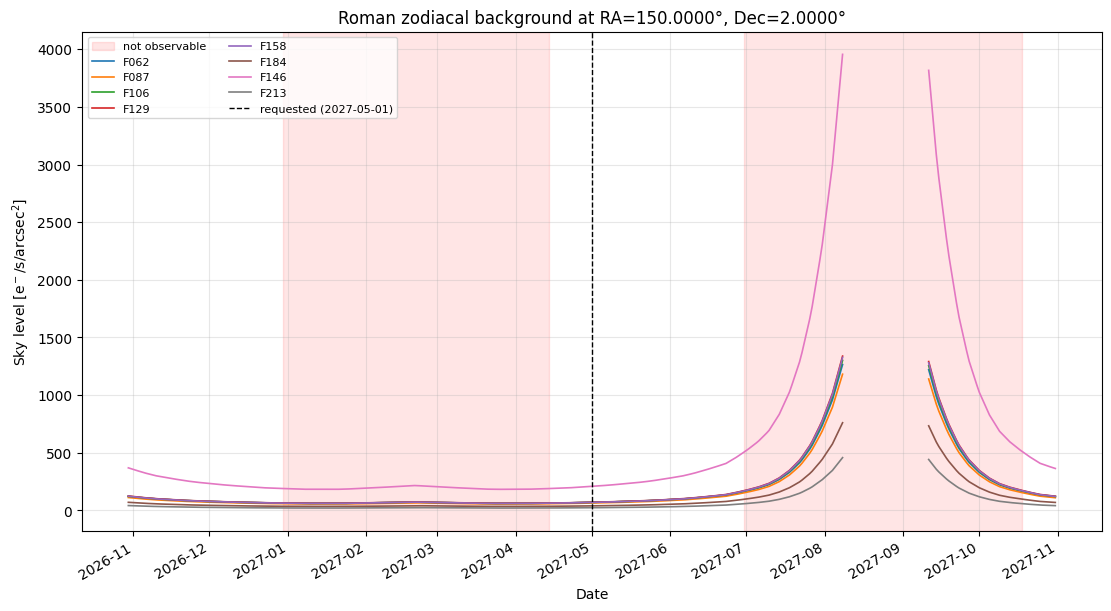

In [16]:
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

# shade disallowed regions
i = 0
shaded_label_used = False
while i < len(allowed_mask):
    if not allowed_mask[i]:
        j = i
        while j + 1 < len(allowed_mask) and not allowed_mask[j + 1]:
            j += 1
        ax.axvspan(days[i], days[j], color='red', alpha=0.1,
                   label=None if shaded_label_used else 'not observable')
        shaded_label_used = True
        i = j + 1
    else:
        i += 1

for b in bands_to_plot:
    ax.plot(days, sky[b], label=gs_to_f.get(b, b), lw=1.2)

ax.axvline(date, color='k', ls='--', lw=1, label=f'requested ({date.date()})')

ax.set_xlabel('Date')
ax.set_ylabel('Sky level [e$^-$/s/arcsec$^2$]')
ax.set_title(f'Roman zodiacal background at RA={ra:.4f}°, Dec={dec:.4f}°')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
ax.legend(loc='best', ncol=2, fontsize=8)
ax.grid(alpha=0.3)
plt.savefig('figures/check_roman_observability/zodiacal_background.png', dpi=300)
plt.show()

In [17]:
## Sky level at the requested date (NaN if not observable).
print(f'Sky level at {date.isoformat()} [e-/s/arcsec^2]:')
for b in bands_to_plot:
    bp = bandpasses[b]
    try:
        val = gs_roman.getSkyLevel(bp, world_pos=world_pos, exptime=1.0, date=date)
        print(f'  {gs_to_f.get(b, b)} ({b}): {val:.4f}')
    except Exception as e:
        print(f'  {gs_to_f.get(b, b)} ({b}): error ({e})')

Sky level at 2027-05-01T00:00:00 [e-/s/arcsec^2]:
  F062 (R062): 70.0299
  F087 (Z087): 63.9640
  F106 (Y106): 69.6086
  F129 (J129): 70.8237
  F158 (H158): 69.5329
  F184 (F184): 39.5592
  F146 (W146): 208.8685
  F213 (K213): 23.6942
